기존의 CV의 경우, std/avg로 계산함. 

근데, EK-LLM 같은 경우에는 MASE, SMAPE의 avg가 작기 때문에, 상대적으로 std가 더 커져서 cv가 커짐. 

즉, “Feature selection 방법의 Robustness Analysis” 를 분석하기 위해서, 

-> EK-LLM이 “성능만 좋아지는 게 아니라 일관성도 유지한다”를 보여주는 게 목적이기 때문에, 

➡️ 보정 CV (std / mean(ALL))를 사용. (보정 CV는 baseline 기준으로 정규화)

In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_cv_by_dataset(data_dict, title_prefix):
    """
    data_dict: {
        "Feature Selection": [...],
        "<MODEL>_CV_MASE": [...],
        "<MODEL>_CV_SMAPE": [...]
        ...
    }
    title_prefix: "EPC" or "UMass" 등
    """
    df = pd.DataFrame(data_dict)

    # 모델 키 자동 탐색
    mase_cols = [c for c in df.columns if c.endswith("_CV_MASE")]
    smape_cols = [c for c in df.columns if c.endswith("_CV_SMAPE")]

    # 모델명 추출
    models_mase = [c.replace("_CV_MASE", "") for c in mase_cols]
    models_smape = [c.replace("_CV_SMAPE", "") for c in smape_cols]
    models = [m for m in models_mase if m in models_smape]

    # 평균 열 추가
    df["Average_CV_MASE"] = df[[f"{m}_CV_MASE" for m in models]].mean(axis=1)
    df["Average_CV_SMAPE"] = df[[f"{m}_CV_SMAPE" for m in models]].mean(axis=1)

    # X축 위치와 막대 너비 설정
    x = np.arange(len(df))
    n_models = len(models)
    bar_width = 0.6 / max(n_models, 1)  # 막대 폭을 더 얇게
    spacing = 0.03  # feature selection 간 간격

    # 모델 색상 (4번째는 purple)
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "purple"]

    # ===== CV_MASE =====
    plt.figure(figsize=(14, 5))
    for i, m in enumerate(models):
        plt.bar(x + (i - (n_models - 1)/2) * (bar_width + spacing),
                df[f"{m}_CV_MASE"],
                width=bar_width,
                label=m,
                color=colors[i % len(colors)])

    # 평균 점선 (검정색)
    plt.plot(x, df["Average_CV_MASE"],
             linestyle='--',
             marker='o',
             color='black',
             label="Average")

    plt.xticks(x, df["Feature Selection"], rotation=45, ha="right")
    plt.ylabel("CV_MASE")
    plt.title(f"{title_prefix}")
    plt.legend()
    plt.tight_layout()
    
    save_name = 'results/cvs/{}_cv_mase.png'.format(title_prefix)
    plt.savefig(save_name)
    
    plt.show()

    # ===== CV_SMAPE =====
    plt.figure(figsize=(14, 5))
    for i, m in enumerate(models):
        plt.bar(x + (i - (n_models - 1)/2) * (bar_width + spacing),
                df[f"{m}_CV_SMAPE"],
                width=bar_width,
                label=m,
                color=colors[i % len(colors)])

    # 평균 점선 (검정색)
    plt.plot(x, df["Average_CV_SMAPE"],
             linestyle='--',
             marker='o',
             color='black',
             label="Average")

    plt.xticks(x, df["Feature Selection"], rotation=45, ha="right")
    plt.ylabel("CV_SMAPE")
    # plt.title(f"{title_prefix}")
    plt.legend()
    plt.tight_layout()
    
    save_name = 'results/cvs/{}_cv_smape.png'.format(title_prefix)
    plt.savefig(save_name)
    
    plt.show()
    


### 장기

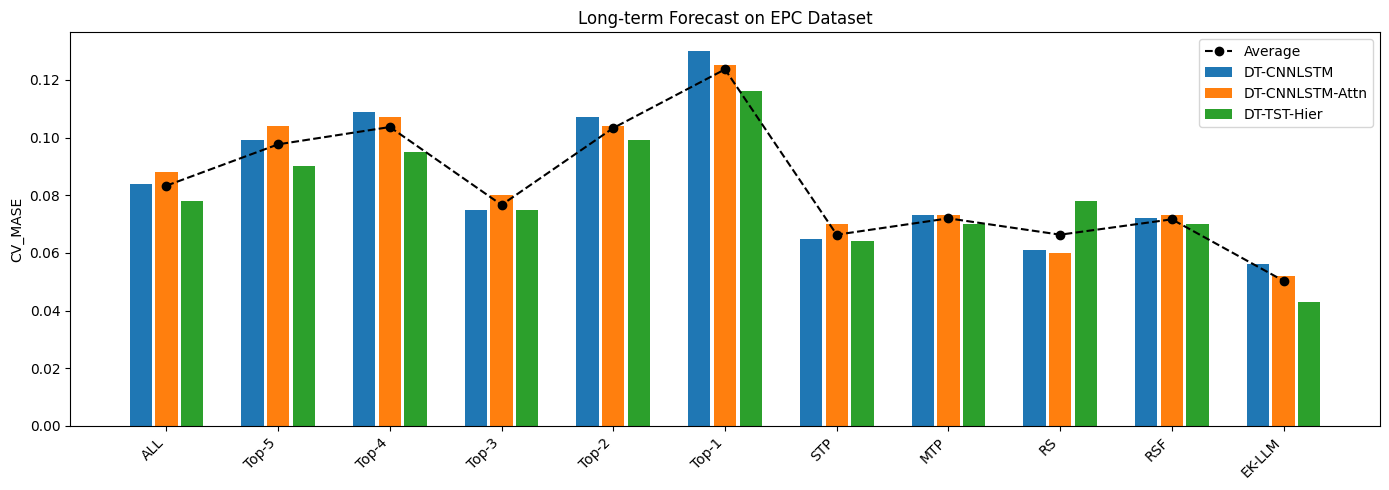

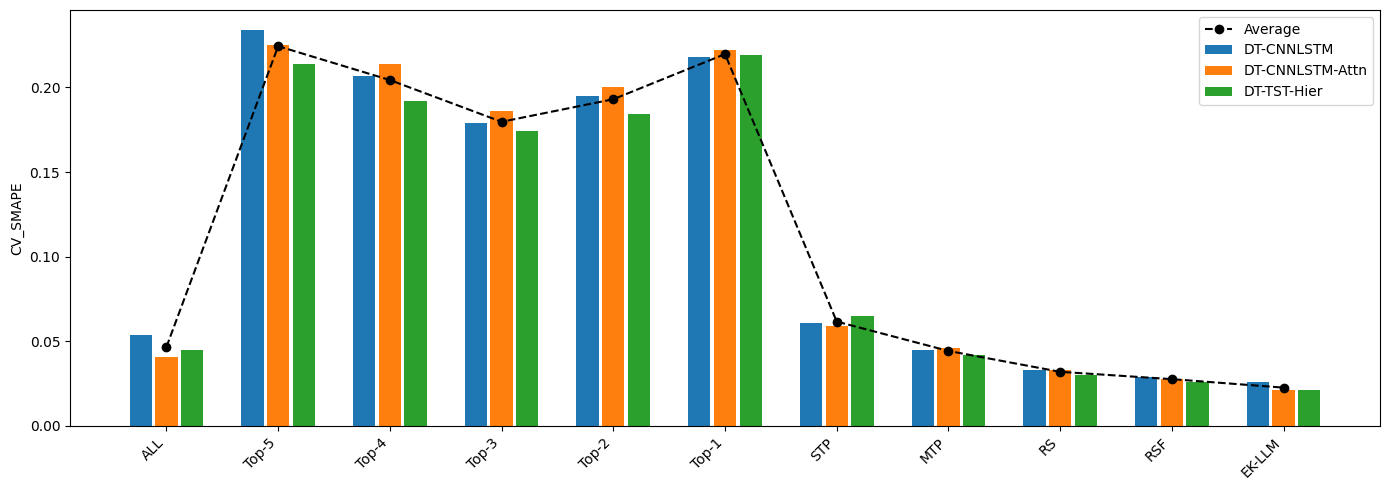

In [99]:
epc_data = {
    "Feature Selection": ["ALL", "Top-5", "Top-4", "Top-3", "Top-2", "Top-1", "STP", "MTP", "RS", "RSF", "EK-LLM"],

    "DT-CNNLSTM_CV_MASE":      [0.084, 0.099, 0.109, 0.075, 0.107, 0.130, 0.065, 0.073, 0.061, 0.072, 0.056],
    "DT-CNNLSTM-Attn_CV_MASE": [0.088, 0.104, 0.107, 0.080, 0.104, 0.125, 0.070, 0.073, 0.060, 0.073, 0.052],
    "DT-TST-Hier_CV_MASE":     [0.078, 0.090, 0.095, 0.075, 0.099, 0.116, 0.064, 0.070, 0.078, 0.070, 0.043],

    "DT-CNNLSTM_CV_SMAPE":      [0.054, 0.234, 0.207, 0.179, 0.195, 0.218, 0.061, 0.045, 0.033, 0.029, 0.026],
    "DT-CNNLSTM-Attn_CV_SMAPE": [0.041, 0.225, 0.214, 0.186, 0.200, 0.222, 0.059, 0.046, 0.033, 0.028, 0.021],
    "DT-TST-Hier_CV_SMAPE":     [0.045, 0.214, 0.192, 0.174, 0.184, 0.219, 0.065, 0.042, 0.030, 0.026, 0.021],
}

plot_cv_by_dataset(epc_data, title_prefix="Long-term Forecast on EPC Dataset")

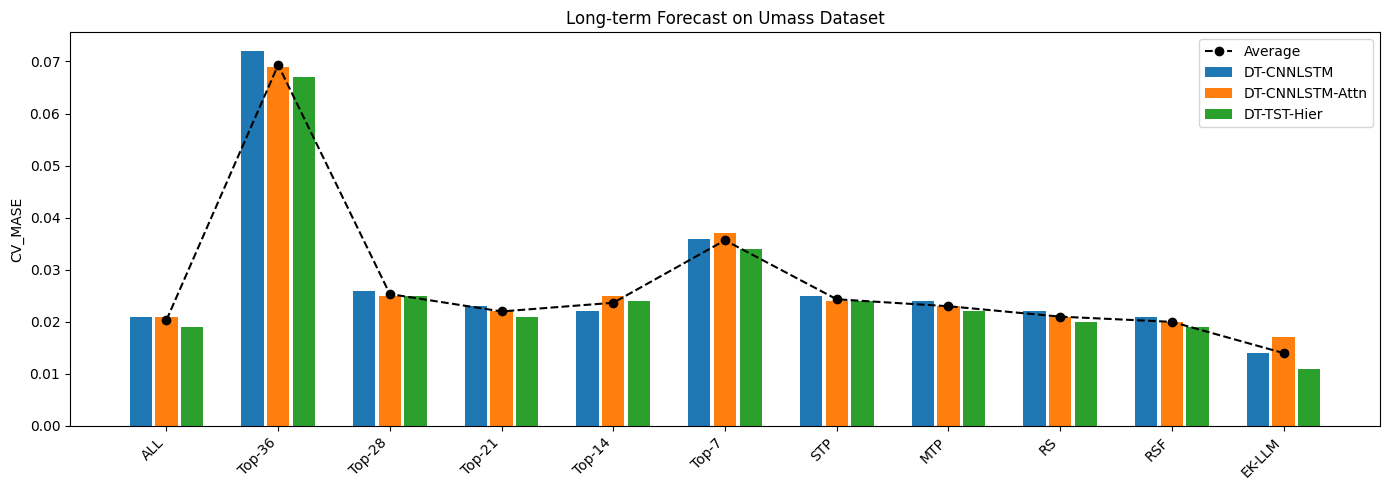

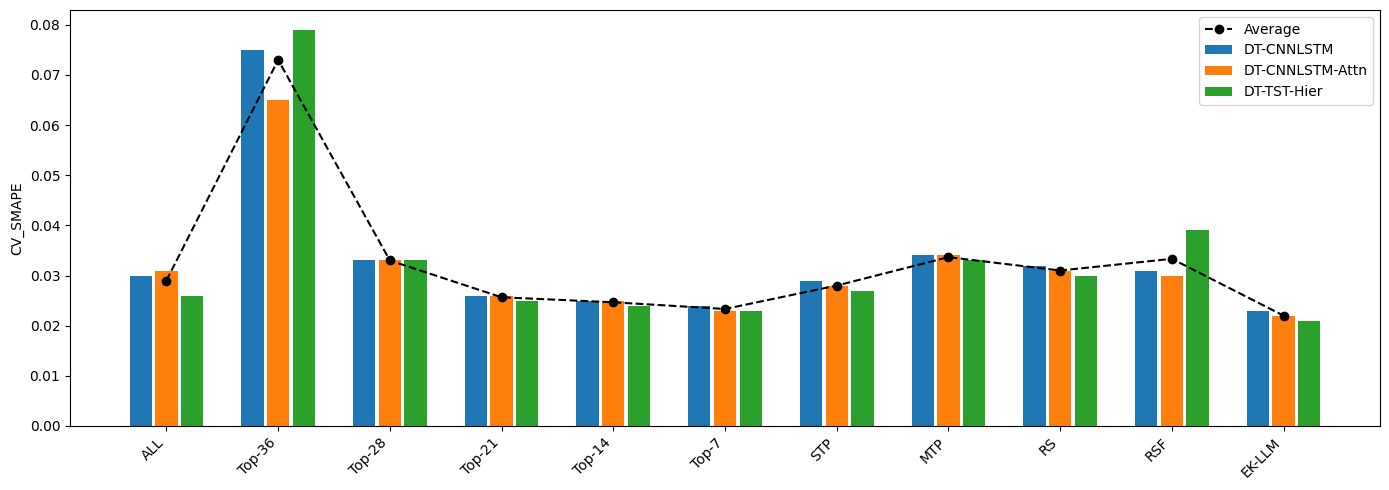

In [101]:
umass_data = {
    "Feature Selection": ["ALL", "Top-36", "Top-28", "Top-21", "Top-14", "Top-7", "STP", "MTP", "RS", "RSF", "EK-LLM"],

    "DT-CNNLSTM_CV_MASE":      [0.021, 0.072, 0.026, 0.023, 0.022, 0.036, 0.025, 0.024, 0.022, 0.021, 0.014],
    "DT-CNNLSTM-Attn_CV_MASE": [0.021, 0.069, 0.025, 0.022, 0.025, 0.037, 0.024, 0.023, 0.021, 0.020, 0.017],
    "DT-TST-Hier_CV_MASE":     [0.019, 0.067, 0.025, 0.021, 0.024, 0.034, 0.024, 0.022, 0.020, 0.019, 0.011],

    "DT-CNNLSTM_CV_SMAPE":      [0.030, 0.075, 0.033, 0.026, 0.025, 0.024, 0.029, 0.034, 0.032, 0.031, 0.023],
    "DT-CNNLSTM-Attn_CV_SMAPE": [0.031, 0.065, 0.033, 0.026, 0.025, 0.023, 0.028, 0.034, 0.031, 0.030, 0.022],
    "DT-TST-Hier_CV_SMAPE":     [0.026, 0.079, 0.033, 0.025, 0.024, 0.023, 0.027, 0.033, 0.030, 0.039, 0.021],
}
plot_cv_by_dataset(umass_data, title_prefix="Long-term Forecast on Umass Dataset")

## 단기

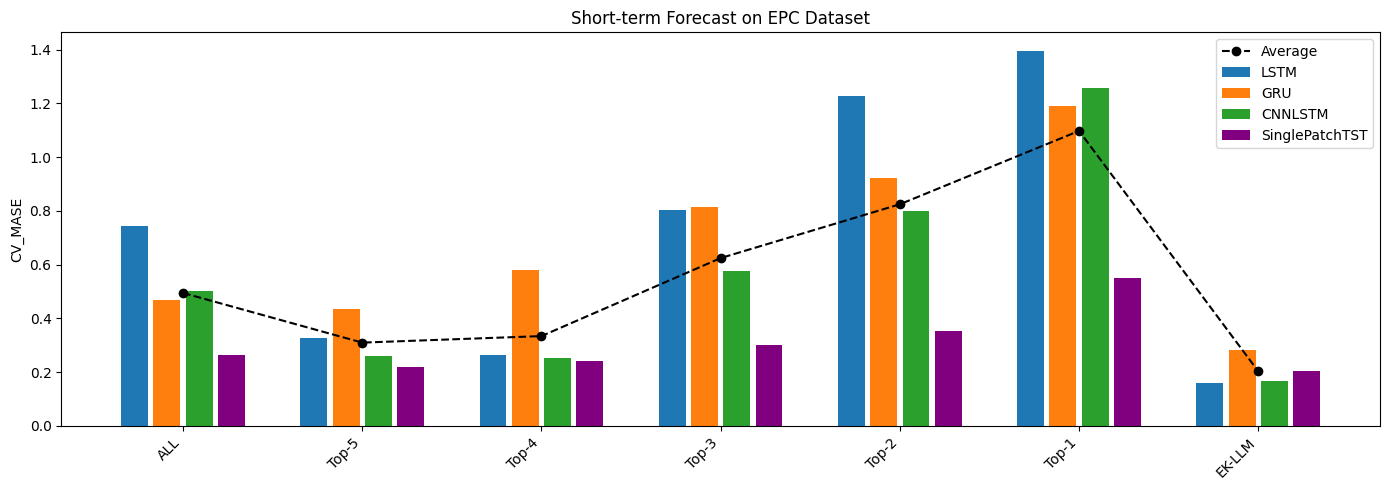

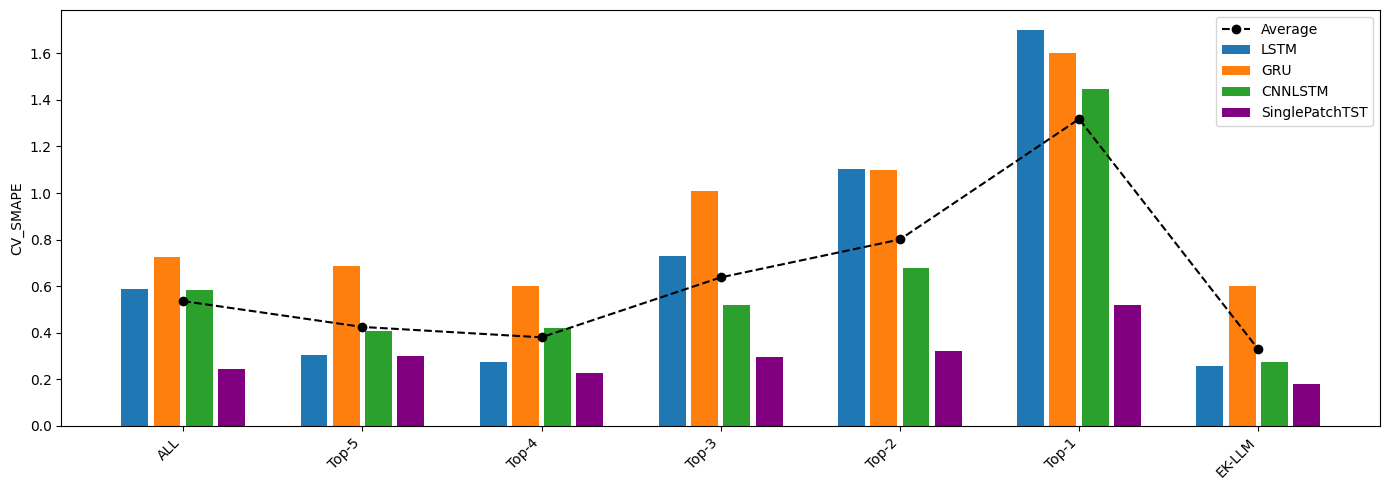

In [102]:
epc_data = {
    "Feature Selection": ["ALL", "Top-5", "Top-4", "Top-3", "Top-2", "Top-1", "EK-LLM"],
    "LSTM_CV_MASE":            [0.744, 0.329, 0.264, 0.804, 1.226, 1.395, 0.161],
    "GRU_CV_MASE":             [0.470, 0.435, 0.580, 0.816, 0.921, 1.189, 0.282],
    "CNNLSTM_CV_MASE":         [0.503, 0.259, 0.254, 0.578, 0.800, 1.259, 0.168],
    "SinglePatchTST_CV_MASE":  [0.263, 0.218, 0.240, 0.301, 0.353, 0.549, 0.203],

    "LSTM_CV_SMAPE":           [0.588, 0.305, 0.276, 0.728, 1.105, 1.701, 0.259],
    "GRU_CV_SMAPE":            [0.727, 0.689, 0.599, 1.010, 1.099, 1.603, 0.602],
    "CNNLSTM_CV_SMAPE":        [0.585, 0.407, 0.421, 0.519, 0.679, 1.447, 0.275],
    "SinglePatchTST_CV_SMAPE": [0.245, 0.300, 0.227, 0.295, 0.320, 0.521, 0.181]
}

plot_cv_by_dataset(epc_data, title_prefix="Short-term Forecast on EPC Dataset")

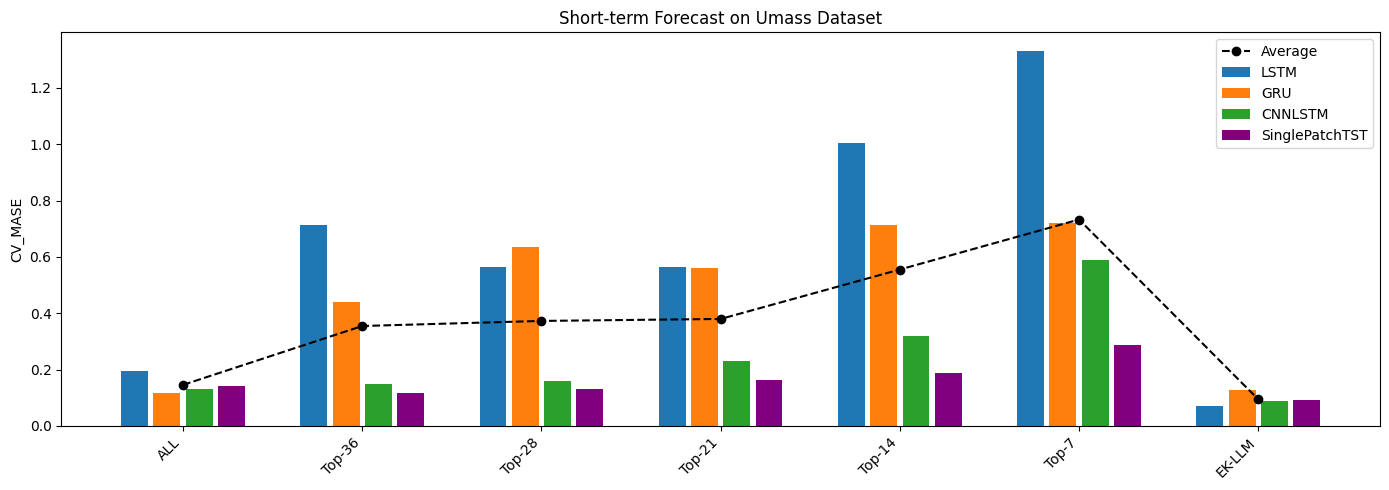

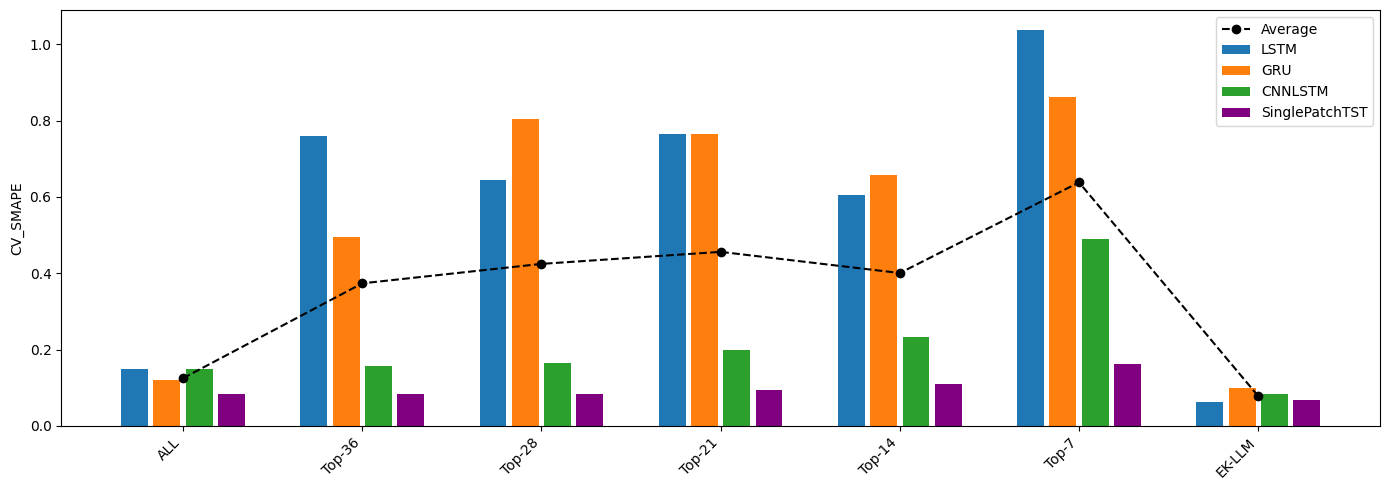

In [103]:
umass_data = {
    "Feature Selection": ["ALL", "Top-36", "Top-28", "Top-21", "Top-14", "Top-7", "EK-LLM"],
    "LSTM_CV_MASE":           [0.194, 0.715, 0.564, 0.564, 1.004, 1.331, 0.071],
    "GRU_CV_MASE":            [0.116, 0.439, 0.636, 0.561, 0.712, 0.722, 0.127],
    "CNNLSTM_CV_MASE":        [0.133, 0.149, 0.159, 0.231, 0.318, 0.590, 0.087],
    "SinglePatchTST_CV_MASE": [0.141, 0.117, 0.133, 0.164, 0.188, 0.289, 0.094],

    "LSTM_CV_SMAPE":           [0.149, 0.760, 0.645, 0.766, 0.604, 1.038, 0.062],
    "GRU_CV_SMAPE":            [0.120, 0.495, 0.805, 0.765, 0.658, 0.863, 0.100],
    "CNNLSTM_CV_SMAPE":        [0.149, 0.157, 0.164, 0.200, 0.232, 0.490, 0.083],
    "SinglePatchTST_CV_SMAPE": [0.083, 0.083, 0.085, 0.094, 0.109, 0.162, 0.068]
}


plot_cv_by_dataset(umass_data, title_prefix="Short-term Forecast on Umass Dataset")